# Imports & Setup

In [24]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import yaml
import logging
import traceback
import warnings

from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
from netCDF4 import Dataset
from pathlib import Path
from numpy import nan as NA

from motif.data.resampling import regrid

In [26]:
# context initialization
with initialize(version_base=None, config_path="../configs"):
    cfg = compose(
        config_name="preproc",
        overrides=["paths=local"],
    )
paths = cfg["paths"]

# Looking at the raw overpass files

In [27]:
granules_files = list(Path(paths["gpm_granules_dir"]).glob("*.HDF5"))
print(f"Found {len(granules_files)} granules files.")

Found 97 granules files.


In [28]:
ds = Dataset(granules_files[0])
ds

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    FileHeader: DOI=10.5067/GPM/SSMIS/F16/1C/07;
DOIauthority=http://dx.doi.org/;
DOIshortName=1CF16SSMIS;
AlgorithmID=1CSSMIS;
AlgorithmVersion=2021-V;
FileName=1C.F16.SSMIS.XCAL2021-V.20220903-S013551-E031745.097399.V07A.HDF5;
SatelliteName=F16;
InstrumentName=SSMIS;
GenerationDateTime=2022-09-05T11:00:57.000Z;
StartGranuleDateTime=2022-09-03T01:35:51.800Z;
StopGranuleDateTime=2022-09-03T03:17:46.800Z;
GranuleNumber=097399;
NumberOfSwaths=4;
NumberOfGrids=0;
GranuleStart=SOUTHERNMOST_LATITUDE;
TimeInterval=ORBIT;
ProcessingSystem=PPS;
ProductVersion=V07A;
EmptyGranule=NOT_EMPTY;
MissingData=0;

    InputRecord: InputFileNames=1Base.F16.SSMIS.TB2021.20220903-S013551-E031745.097399.V07A.HDF5,NPR.TDRN.SA.D22246.S0026.E0209.B9739900.NS,NPR.TDRN.SA.D22246.S0206.E0353.B9740001.NS;
InputAlgorithmVersions=2021,100,100;
InputGenerationDateTimes=2022-09-05T11:00:40.000Z,9999-99-99T99:99:99.999Z,9999-99-99T99:99:99.999

The ```S1``` group contains the data for the first swath. The number of swath depends on the instrument.

In [29]:
s1 = ds["S1"]
s1

<class 'netCDF4.Group'>
group /S1:
    S1_SwathHeader: NumberScansInSet=1;
MaximumNumberScansTotal=4000;
NumberScansBeforeGranule=0;
NumberScansGranule=3221;
NumberScansAfterGranule=0;
NumberPixels=90;
ScanType=CONICAL;

    S1_IncidenceAngleIndex: IncidenceAngleIndex=1,1,1;

    dimensions(sizes): phony_dim_2(3221), phony_dim_3(90), phony_dim_4(1), phony_dim_5(3)
    variables(dimensions): float32 Latitude(phony_dim_2, phony_dim_3), float32 Longitude(phony_dim_2, phony_dim_3), float32 sunLocalTime(phony_dim_2, phony_dim_3), int8 Quality(phony_dim_2, phony_dim_3), float32 incidenceAngle(phony_dim_2, phony_dim_3, phony_dim_4), int8 sunGlintAngle(phony_dim_2, phony_dim_3, phony_dim_4), int8 incidenceAngleIndex(phony_dim_2, phony_dim_5), float32 Tc(phony_dim_2, phony_dim_3, phony_dim_5)
    groups: ScanTime, SCstatus

In [30]:
tc = s1["Tc"][:]
print(f"Loaded Tc with shape {tc.shape} and values from {tc.min()} to {tc.max()}")

Loaded Tc with shape (3221, 90, 3) and values from 98.41000366210938 to 300.82000732421875


Let's look at the scan times:

In [31]:
def build_timestamp(year, day_of_year, second_of_day):
    """Vectorized conversion from GPM scan fields to timestamps."""
    # Convert to masked arrays
    years = np.ma.asarray(year)
    days = np.ma.asarray(day_of_year)
    seconds = np.ma.asarray(second_of_day)

    # Combine masks to propagate missing data
    mask = np.ma.getmaskarray(years) | np.ma.getmaskarray(days) | np.ma.getmaskarray(seconds)
    # Fill masked values with 1970-01-01 00:00:00 (what a surprising choice!)
    years_flat = years.filled(1970).reshape(-1)
    days_flat = days.filled(1).reshape(-1)
    seconds_flat = seconds.filled(0).reshape(-1)

    base_dates = pd.to_datetime(years_flat.astype(int), format="%Y")
    timestamps = base_dates + pd.to_timedelta(days_flat - 1, unit="D")
    timestamps += pd.to_timedelta(seconds_flat, unit="s")

    ts_array = timestamps.to_numpy().reshape(years.shape)
    if mask.any():
        ts_array = np.where(mask, np.datetime64("NaT"), ts_array)

    return ts_array

In [32]:
scan_time_group = s1["ScanTime"]
year = scan_time_group["Year"][:]
day_of_year = scan_time_group["DayOfYear"][:]
second_of_day = scan_time_group["SecondOfDay"][:]
scan_times = build_timestamp(year, day_of_year, second_of_day)
print(f"First scan time: {scan_times[0]}, Last scan time: {scan_times[-1]}")

First scan time: 2022-09-03T01:35:52.509000000, Last scan time: 2022-09-03T03:17:46.331000000


Let's now check the Brightness Temperature:

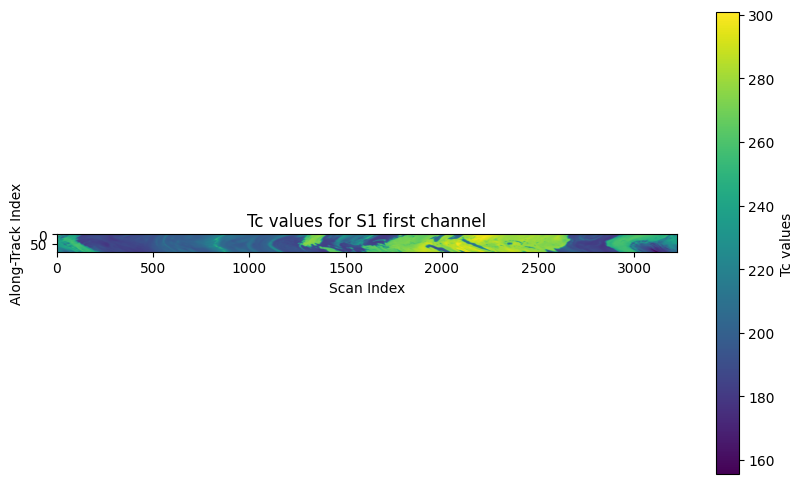

In [33]:
plt.figure(figsize=(10, 6))
plt.imshow(tc[:, :, 0].T, cmap="viridis")
plt.colorbar(label="Tc values")
plt.title("Tc values for S1 first channel")
plt.xlabel("Scan Index")
plt.ylabel("Along-Track Index")
plt.show()

# Checking the coincidences

Let's load the coincidences dataframe to begin with:

In [34]:
coin_df = pd.read_csv(paths['gpm_coincidences_csv'])
# Convert the time columns to datetime
coin_df['start_time'] = pd.to_datetime(coin_df['start_time']).dt.tz_localize(None)
coin_df['end_time'] = pd.to_datetime(coin_df['end_time']).dt.tz_localize(None)
coin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   day           45 non-null     object        
 1   sensat_A      45 non-null     object        
 2   sensat_B      45 non-null     object        
 3   start_time    45 non-null     datetime64[ns]
 4   end_time      45 non-null     datetime64[ns]
 5   min_distance  45 non-null     float64       
 6   max_distance  45 non-null     float64       
 7   url_A         45 non-null     object        
 8   url_B         45 non-null     object        
 9   file_A        45 non-null     object        
 10  file_B        45 non-null     object        
dtypes: datetime64[ns](2), float64(2), object(7)
memory usage: 4.0+ KB


In [35]:
coin_df.head()

,day,sensat_A,sensat_B,start_time,end_time,min_distance,max_distance,url_A,url_B,file_A,file_B
0,2022-09-01,AMSR2_GCOMW1,SSMIS_F18,2022-09-01 17:28:00,2022-09-01 17:30:00,131.749296,309.418159,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,1C.GCOMW1.AMSR2.XCAL2016-V.20220901-S164048-E1...,1C.F18.SSMIS.XCAL2021-V.20220901-S163716-E1819...
1,2022-09-01,GMI_GPM,SSMIS_F17,2022-09-01 07:23:00,2022-09-01 07:25:00,37.280003,347.288878,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,1C-R.GPM.GMI.XCAL2016-C.20220901-S062642-E0759...,1C.F17.SSMIS.XCAL2021-V.20220901-S061941-E0801...
2,2022-09-03,GMI_GPM,SSMIS_F16,2022-09-03 18:45:00,2022-09-03 18:47:00,181.990900,428.214172,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,1C-R.GPM.GMI.XCAL2016-C.20220903-S183720-E2009...,1C.F16.SSMIS.XCAL2021-V.20220903-S183502-E2016...
3,2022-09-04,AMSR2_GCOMW1,SSMIS_F18,2022-09-04 00:40:00,2022-09-04 00:43:00,134.675626,443.580295,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,1C.GCOMW1.AMSR2.XCAL2016-V.20220904-S004248-E0...,1C.F18.SSMIS.XCAL2021-V.20220904-S004054-E0222...
4,2022-09-06,AMSR2_GCOMW1,SSMIS_F18,2022-09-06 07:53:00,2022-09-06 07:56:00,94.875338,434.507847,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,https://arthurhouhttps.pps.eosdis.nasa.gov/gpm...,1C.GCOMW1.AMSR2.XCAL2016-V.20220906-S070556-E0...,1C.F18.SSMIS.XCAL2021-V.20220906-S070237-E0844...


In [36]:
# We'll look at the first coincidence. Since we don't know which sensats it will be
# (where sensat is a string SENSOR_SATELLITE), we'll fetch in the preproc hydra config
# a dict {SENSOR: {swath: channel indices}} which will let us know where in the NetCDF
# dataset to look for the right channels.
channel_map = cfg['gpm']['channel_map']
first_coin = coin_df.iloc[0]
sensor_A = first_coin["sensat_A"].split('_')[0]  # E.g. "GMI"
sensor_B = first_coin["sensat_B"].split('_')[0]
map_A = channel_map[sensor_A]  # E.g. {"S1": [4, 5, 6, 7]}
map_B = channel_map[sensor_B]
first_swath_A, first_swath_B = list(map_A.keys())[0], list(map_B.keys())[0]
first_channel_idx_A, first_channel_idx_B = map_A[first_swath_A][0], map_B[first_swath_B][0]

granules_dir = Path(paths["gpm_granules_dir"])
path_A = granules_dir / Path(first_coin["file_A"])
path_B = granules_dir / Path(first_coin["file_B"])
# Load the datasets' first swath groups using xarray
ds_A = xr.open_dataset(path_A, group=first_swath_A)
ds_B = xr.open_dataset(path_B, group=first_swath_B)
# Gets the scan and pixel dimension names
scan_dim_A, pixel_dim_A = ds_A['Latitude'].dims
scan_dim_B, pixel_dim_B = ds_B['Latitude'].dims

# The ScanTime variable is stored in the "ScanTime" subgroup of each swath group
with Dataset(path_A) as st_A:
    stA_swath = st_A[first_swath_A]['ScanTime']
    year_A = stA_swath["Year"][:]
    day_of_year_A = stA_swath["DayOfYear"][:]
    second_of_day_A = stA_swath["SecondOfDay"][:]
scan_times_A = build_timestamp(year_A, day_of_year_A, second_of_day_A).astype("datetime64[ns]")
with Dataset(path_B) as st_B:
    stB_swath = st_B[first_swath_B]['ScanTime']
    year_B = stB_swath["Year"][:]
    day_of_year_B = stB_swath["DayOfYear"][:]
    second_of_day_B = stB_swath["SecondOfDay"][:]
scan_times_B = build_timestamp(year_B, day_of_year_B, second_of_day_B).astype("datetime64[ns]")

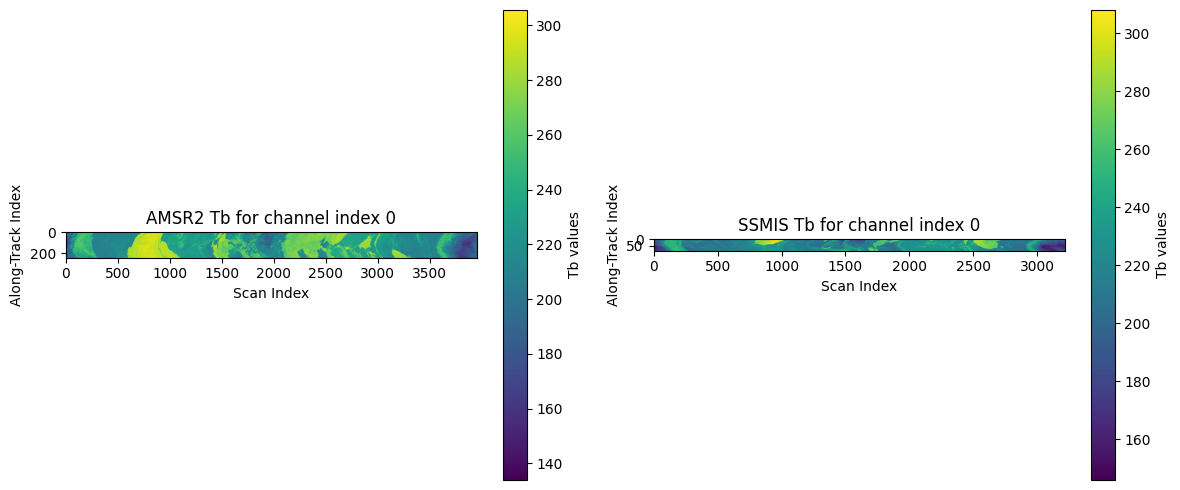

In [37]:
# Plots the brightness temperatures for the first channel of each sensor
tb_A = ds_A["Tc"][:, :, first_channel_idx_A]
tb_B = ds_B["Tc"][:, :, first_channel_idx_B]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(tb_A.T, cmap="viridis")
plt.colorbar(label="Tb values")
plt.title(f"{sensor_A} Tb for channel index {first_channel_idx_A}")
plt.xlabel("Scan Index")
plt.ylabel("Along-Track Index")
plt.subplot(1, 2, 2)
plt.imshow(tb_B.T, cmap="viridis")
plt.colorbar(label="Tb values")
plt.title(f"{sensor_B} Tb for channel index {first_channel_idx_B}")
plt.xlabel("Scan Index")
plt.ylabel("Along-Track Index")
plt.tight_layout()
plt.show()

Let's compare the times of the granules and their distances during the supposed coincidence:

In [38]:
print(f"{sensor_A} First scan time: {scan_times_A[0]}, Last scan time: {scan_times_A[-1]}")
print(f"{sensor_B} First scan time: {scan_times_B[0]}, Last scan time: {scan_times_B[-1]}")

AMSR2 First scan time: 2022-09-01T16:40:49.614000000, Last scan time: 2022-09-01T18:19:41.545000000
SSMIS First scan time: 2022-09-01T16:37:16.709000000, Last scan time: 2022-09-01T18:19:10.517000000


In [39]:
# Isolate the times that are within the coincidence window
mask_A = (scan_times_A >= first_coin["start_time"]) & (scan_times_A <= first_coin["end_time"])
mask_B = (scan_times_B >= first_coin["start_time"]) & (scan_times_B <= first_coin["end_time"])
print(f"{sensor_A} Number of scans in coincidence window: {mask_A.sum()}")
print(f"{sensor_B} Number of scans in coincidence window: {mask_B.sum()}")

ds_A = ds_A.sel({scan_dim_A: np.where(mask_A)[0]})
ds_B = ds_B.sel({scan_dim_B: np.where(mask_B)[0]})

AMSR2 Number of scans in coincidence window: 80
SSMIS Number of scans in coincidence window: 64


Let's now plot the parts of the granules that are within the coincidence windows:

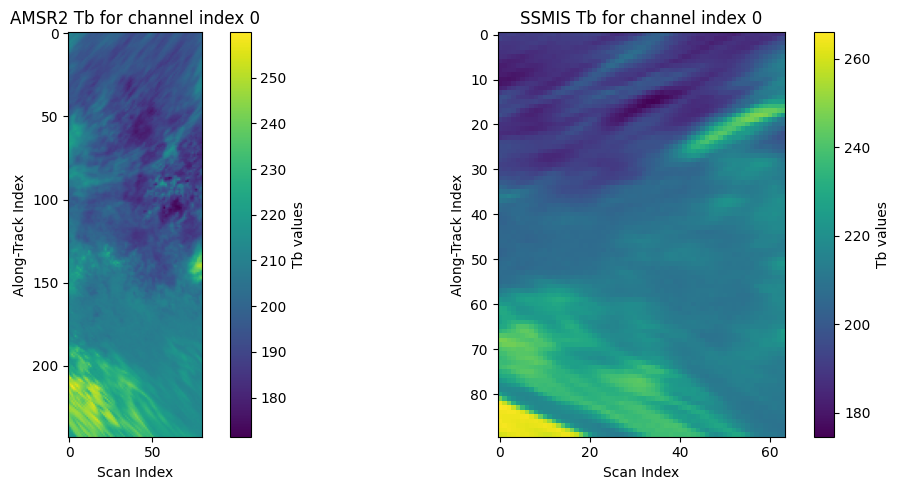

In [40]:
# Plots the brightness temperatures for the first channel of each sensor
tb_A = ds_A["Tc"][:, :, first_channel_idx_A]
tb_B = ds_B["Tc"][:, :, first_channel_idx_B]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(tb_A.T, cmap="viridis")
plt.colorbar(label="Tb values")
plt.title(f"{sensor_A} Tb for channel index {first_channel_idx_A}")
plt.xlabel("Scan Index")
plt.ylabel("Along-Track Index")
plt.subplot(1, 2, 2)
plt.imshow(tb_B.T, cmap="viridis")
plt.colorbar(label="Tb values")
plt.title(f"{sensor_B} Tb for channel index {first_channel_idx_B}")
plt.xlabel("Scan Index")
plt.ylabel("Along-Track Index")
plt.tight_layout()
plt.show()

# Regridding swaths
We'll use the ```regrid``` method from ```motif.data.resampling```, which regrids the swaths to an LAEA grid:

In [41]:
def prepare_swath_ds(ds):
    """Prepares a swath dataset to match the format expected by regrid()."""
    # Rename lat/lon variables to standard names
    ds = ds.rename({"Latitude": "latitude", "Longitude": "longitude"})
    # Select only the required variables
    ds = ds[["latitude", "longitude", "Tc"]]
    return ds

In [42]:
# Let's apply the resampling to both datasets and plot the results
target_resolution = 5.0  # in km
ds_A_reg = regrid(prepare_swath_ds(ds_A), target_resolution, has_channel_dimension=True)
ds_B_reg = regrid(prepare_swath_ds(ds_B), target_resolution, has_channel_dimension=True)

In [43]:
ds_A_reg

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 177, lon: 358, channel: 2)
Coordinates:
    latitude   (lat, lon) float64 507kB 85.92 85.96 86.0 ... 71.39 71.37 71.34
    longitude  (lat, lon) float64 507kB 80.05 79.85 79.64 ... -132.3 -132.2
Dimensions without coordinates: lat, lon, channel
Data variables:
    Tc         (lat, lon, channel) float64 1MB nan nan nan nan ... nan nan nan

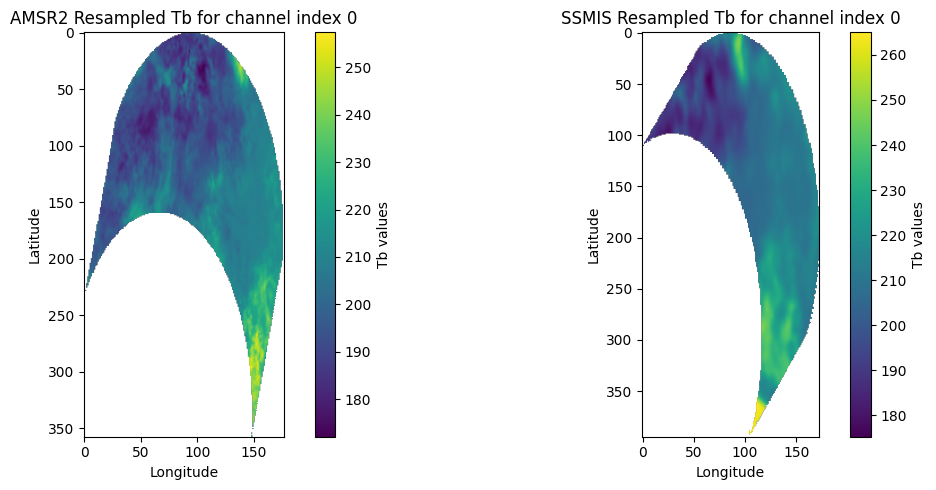

In [44]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(ds_A_reg["Tc"][:, :, first_channel_idx_A].T, cmap="viridis")
plt.colorbar(label="Tb values")
plt.title(f"{sensor_A} Resampled Tb for channel index {first_channel_idx_A}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.subplot(1, 2, 2)
plt.imshow(ds_B_reg["Tc"][:, :, first_channel_idx_B].T, cmap="viridis")
plt.colorbar(label="Tb values")
plt.title(f"{sensor_B} Resampled Tb for channel index {first_channel_idx_B}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()